
# **TUGAS PRAKTIKUM MANDIRI 06 SUPPORT VECTOR MACHINE (SVM)**

# Menghubungkan ke Drive

In [58]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [59]:
path = "/content/drive/MyDrive/Colab Notebooks/Machine Learning/Praktikum06"

# Import Library

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Loading Dataset

In [61]:
import pandas as pd

# membaca file csv menggunakan pandas
df = pd.read_csv(path + '/Data/loan.csv')

# cetak header data (5 baris data) dari file
df.head()

,age,gender,occupation,education_level,marital_status,income,credit_score,loan_status
0,32,Male,Engineer,Bachelor's,Married,85000,720,Approved
1,45,Female,Teacher,Master's,Single,62000,680,Approved
2,28,Male,Student,High School,Single,25000,590,Denied
3,51,Female,Manager,Bachelor's,Married,105000,780,Approved
4,36,Male,Accountant,Bachelor's,Married,75000,710,Approved


In [62]:
# Menampilkan informasi detail
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              61 non-null     int64 
 1   gender           61 non-null     object
 2   occupation       61 non-null     object
 3   education_level  61 non-null     object
 4   marital_status   61 non-null     object
 5   income           61 non-null     int64 
 6   credit_score     61 non-null     int64 
 7   loan_status      61 non-null     object
dtypes: int64(3), object(5)
memory usage: 3.9+ KB


In [63]:
# Menampilkan statistika deskriptif dari dataset
df.describe()

,age,income,credit_score
count,61.000000,61.000000,61.000000
mean,37.081967,78983.606557,709.836066
std,8.424755,33772.025802,72.674888
min,24.000000,25000.000000,560.000000
25%,30.000000,52000.000000,650.000000
50%,36.000000,78000.000000,720.000000
75%,43.000000,98000.000000,770.000000
max,55.000000,180000.000000,830.000000


In [64]:
df.isnull().sum()

,0
age,0
gender,0
occupation,0
education_level,0
marital_status,0
income,0
credit_score,0
loan_status,0


# Menentukan Fitur dan Target

In [65]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (61, 7)
y shape: (61,)


# Membagi Data Training dan Testing

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Jumlah data training:", len(X_train))
print("Jumlah data testing:", len(X_test))

Jumlah data training: 48
Jumlah data testing: 13


# Melakukan Standarisasi

In [67]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

categorical_features = ['gender', 'occupation', 'education_level', 'marital_status']
numerical_features = ['age', 'income', 'credit_score']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Contoh hasil preprocessing dan scaling:\n", X_train_processed[:5])

Contoh hasil preprocessing dan scaling:
 <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 35 stored elements and shape (5, 47)>
  Coords	Values
  (0, 0)	1.6745762293788606
  (0, 1)	0.7210810703432784
  (0, 2)	0.9381095179686104
  (0, 3)	1.0
  (0, 19)	1.0
  (0, 41)	1.0
  (0, 45)	1.0
  (1, 0)	0.8049354054665001
  (1, 1)	0.13194249372238723
  (1, 2)	0.3734793378746509
  (1, 3)	1.0
  (1, 20)	1.0
  (1, 44)	1.0
  (1, 45)	1.0
  (2, 0)	0.43223219521834555
  (2, 1)	1.3102196469641696
  (2, 2)	1.22042460801559
  (2, 3)	1.0
  (2, 22)	1.0
  (2, 42)	1.0
  (2, 45)	1.0
  (3, 0)	-0.06470541844586046
  (3, 1)	0.3381409955396992
  (3, 2)	0.5146368828981407
  (3, 4)	1.0
  (3, 17)	1.0
  (3, 44)	1.0
  (3, 45)	1.0
  (4, 0)	0.5564665986343971
  (4, 1)	1.162935002808947
  (4, 2)	1.0792670629921002
  (4, 4)	1.0
  (4, 18)	1.0
  (4, 42)	1.0
  (4, 45)	1.0


# Membuat dan Melatih Model SVM

In [68]:
model = SVC(kernel='linear', random_state=42)
model.fit(X_train_processed, y_train)
print("Model SVM berhasil dilatih.")

Model SVM berhasil dilatih.


# Prediksi dan Evaluasi Model

In [69]:
y_pred = model.predict(X_test_processed)

print("Akurasi:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Akurasi: 0.9230769230769231

Classification Report:
               precision    recall  f1-score   support

    Approved       1.00      0.89      0.94         9
      Denied       0.80      1.00      0.89         4

    accuracy                           0.92        13
   macro avg       0.90      0.94      0.92        13
weighted avg       0.94      0.92      0.93        13



# Confusion Matrix


Confusion Matrix:
 [[8 1]
 [0 4]]


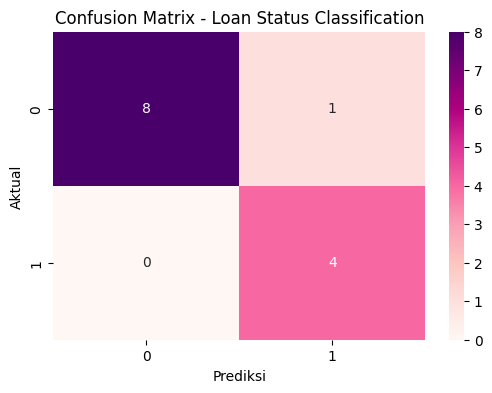

In [70]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu')
plt.title('Confusion Matrix - Loan Status Classification')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

# Visualisasi Hasil Model SVM

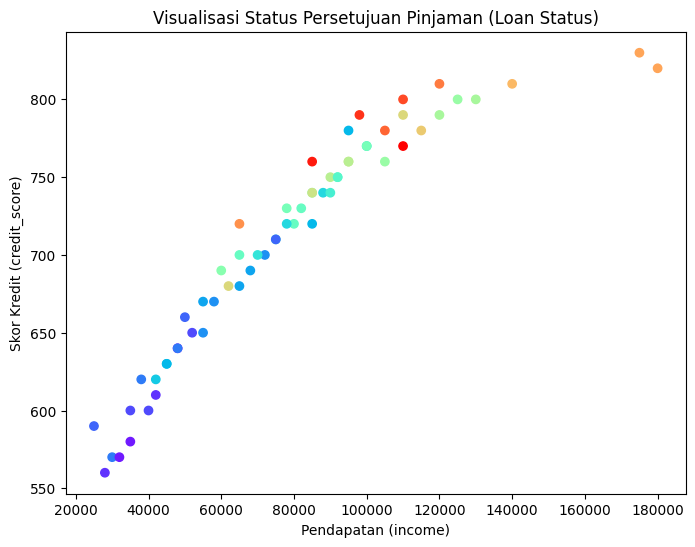

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df['income'], df['credit_score'], c=df['age'], cmap='rainbow')
plt.xlabel('Pendapatan (income)')
plt.ylabel('Skor Kredit (credit_score)')
plt.title('Visualisasi Status Persetujuan Pinjaman (Loan Status)')
plt.show()

# 3D Visualisasi Hasil Model SVM

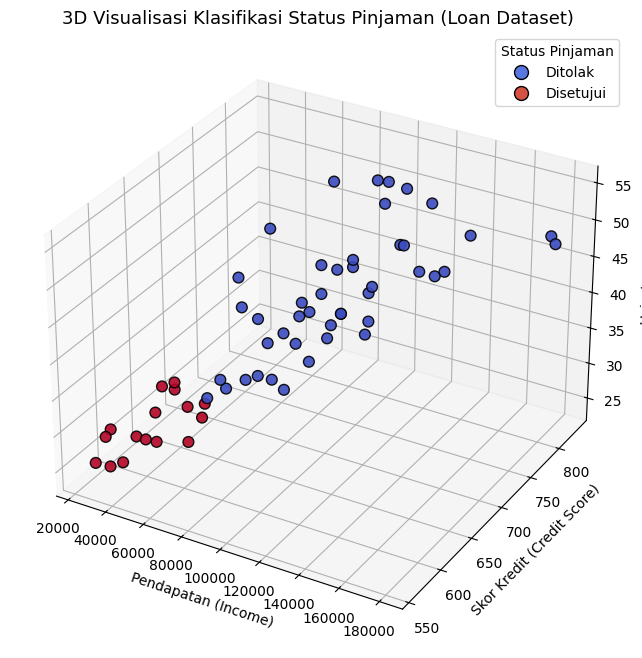

In [74]:
from sklearn.preprocessing import LabelEncoder
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

le = LabelEncoder()
df['LoanStatusEncoded'] = le.fit_transform(df['loan_status'])

x_col = 'income'
y_col = 'credit_score'
z_col = 'age'

colormap = plt.get_cmap('coolwarm')
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
colors = colormap(df['LoanStatusEncoded'] / df['LoanStatusEncoded'].max())
scatter = ax.scatter(
    df[x_col],
    df[y_col],
    df[z_col],
    c=colors,
    s=60,
    edgecolor='k',
    alpha=0.9
)

ax.set_xlabel('Pendapatan (Income)')
ax.set_ylabel('Skor Kredit (Credit Score)')
ax.set_zlabel('Usia (Age)')
ax.set_title('3D Visualisasi Klasifikasi Status Pinjaman (Loan Dataset)', fontsize=13)

from matplotlib.lines import Line2D
custom_lines = [
    Line2D([0], [0], marker='o', color='w', label='Ditolak',
           markerfacecolor=colormap(0.1), markersize=10, markeredgecolor='k'),
    Line2D([0], [0], marker='o', color='w', label='Disetujui',
           markerfacecolor=colormap(0.9), markersize=10, markeredgecolor='k')
]
ax.legend(handles=custom_lines, title='Status Pinjaman')

plt.show()